In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('unified_results_complete.csv')
df = df[df['Category'] == 'Document']

# Calculate average SSIM across all 9 SSIM columns
##ssim_cols = [col for col in df.columns if 'SSIM' in col]
##df['Average_SSIM'] = df[ssim_cols].mean(axis=1)

# Set the requested color mapping
color_map = {
    'HEIC': '#1f77b4',
    'JPEG': '#d62728',
    'WEBP': '#2ca02c',
    'AVIF': '#ff7f0e'
}

In [20]:
df.head()

,Original_Image,Format,Quality_Level,Category,Encoding_Time_sec,VMAF,Compressed_Size_Bytes,Baseline_PNG_Bytes,Storage_Saved_%,Y_MSE,...,Cb_MSE,Cb_PSNR,Cb_SSIM_w7,Cb_SSIM_w11,Cb_SSIM_w21,Cr_MSE,Cr_PSNR,Cr_SSIM_w7,Cr_SSIM_w11,Cr_SSIM_w21
0,DOC01,AVIF,1,Document,2.889598,88.879763,135774.0,1200133.0,88.69,46.050030,...,2.142483,44.821630,0.994157,0.993800,0.993894,0.489980,51.229021,0.997388,0.996507,0.995410
1,DOC01,HEIC,1,Document,3.051515,85.114803,130165.0,1200133.0,89.15,66.611910,...,2.760674,43.720652,0.993552,0.993233,0.993045,0.487283,51.252988,0.997535,0.996590,0.995298
2,DOC01,JPEG,1,Document,0.134471,75.404332,402556.0,1200133.0,66.46,112.586770,...,11.149323,37.658319,0.987268,0.985389,0.983644,5.697846,40.573696,0.997410,0.996743,0.995721
3,DOC01,WEBP,1,Document,2.662278,89.466147,273928.0,1200133.0,77.18,23.773664,...,2.899520,43.507543,0.991964,0.991358,0.991594,0.615816,50.236296,0.997400,0.996635,0.995751
4,DOC02,AVIF,1,Document,2.722397,89.494489,106003.0,947640.0,88.81,34.702350,...,1.292113,47.017799,0.994139,0.992327,0.990272,0.849218,48.840612,0.996217,0.995049,0.993512


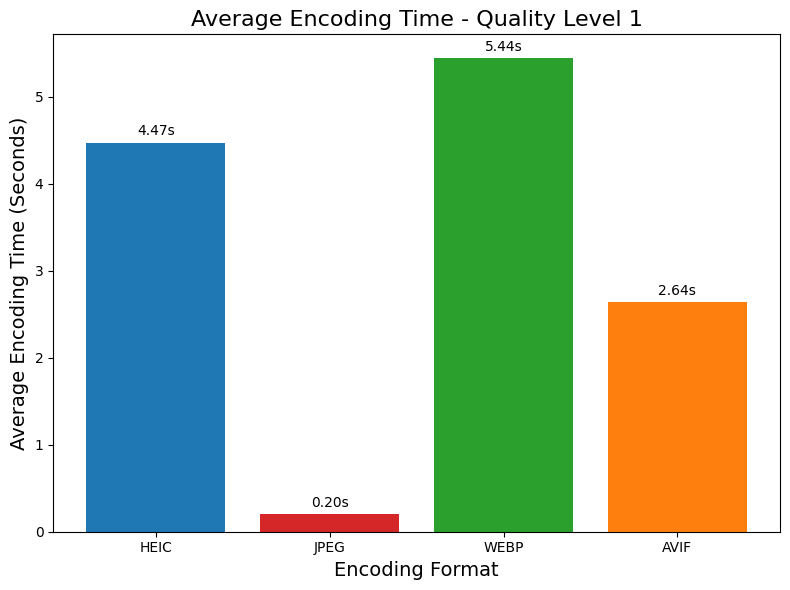

In [21]:
## Calculate average encoding time for each Format at each Quality Level
avg_time_df = df.groupby(['Quality_Level', 'Format'])['Encoding_Time_sec'].mean().reset_index()

# 4. Get the unique quality levels
quality_levels = sorted(df['Quality_Level'].unique())

# Define the order of formats to ensure consistency across charts
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 5. Create and save a separate plot for each quality level
for q_level in quality_levels:
    # Create a new independent figure for each quality level
    plt.figure(figsize=(8, 6))
    
    # Filter data for the current quality level
    subset = avg_time_df[avg_time_df['Quality_Level'] == q_level]
    
    # Extract times and colors in the specified order
    times = []
    colors = []
    labels = []
    
    for fmt in format_order:
        fmt_data = subset[subset['Format'] == fmt]
        if not fmt_data.empty:
            times.append(fmt_data['Encoding_Time_sec'].values[0])
            colors.append(color_map[fmt])
            labels.append(fmt)
            
    # Create the bar chart
    bars = plt.bar(labels, times, color=colors)
    
    # Formatting the plot
    plt.title(f'Average Encoding Time - Quality Level {q_level}', fontsize=16)
    plt.xlabel('Encoding Format', fontsize=14)
    plt.ylabel('Average Encoding Time (Seconds)', fontsize=14)
        
    # Add value labels on top of each bar for readability
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.2f}s',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom')

    # Adjust layout to prevent clipping
    plt.tight_layout()
    
    # Save the individual figure
    plt.show()
    
    # Clear the current figure to start fresh for the next loop iteration
    plt.close()

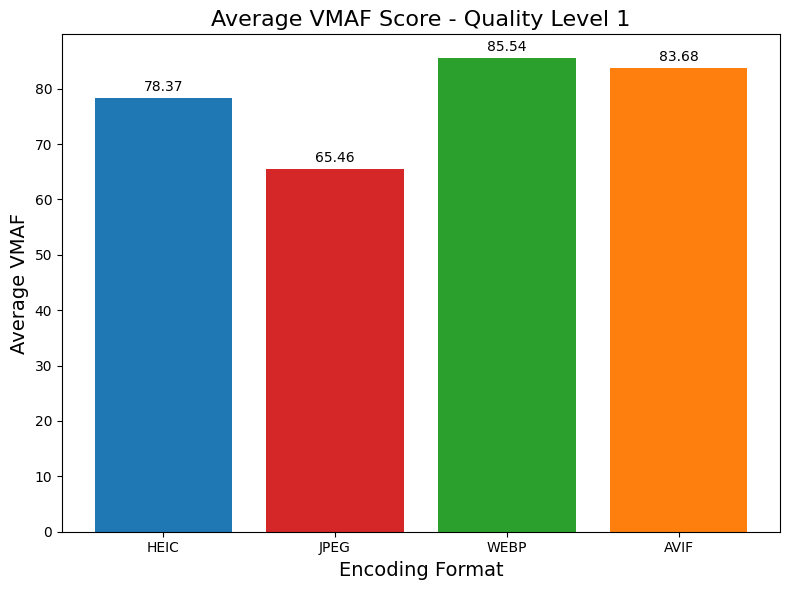

In [22]:
## Calculate average encoding time for each Format at each Quality Level
avg_vmaf_df = df.groupby(['Quality_Level', 'Format'])['VMAF'].mean().reset_index()

# 4. Get the unique quality levels
quality_levels = sorted(df['Quality_Level'].unique())

# Define the order of formats to ensure consistency across charts
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 5. Create and save a separate plot for each quality level
for q_level in quality_levels:
    # Create a new independent figure for each quality level
    plt.figure(figsize=(8, 6))
    
    # Filter data for the current quality level
    subset = avg_vmaf_df[avg_vmaf_df['Quality_Level'] == q_level]
    
    # Extract times and colors in the specified order
    times = []
    colors = []
    labels = []
    
    for fmt in format_order:
        fmt_data = subset[subset['Format'] == fmt]
        if not fmt_data.empty:
            times.append(fmt_data['VMAF'].values[0])
            colors.append(color_map[fmt])
            labels.append(fmt)
            
    # Create the bar chart
    bars = plt.bar(labels, times, color=colors)
    
    # Formatting the plot
    plt.title(f'Average VMAF Score - Quality Level {q_level}', fontsize=16)
    plt.xlabel('Encoding Format', fontsize=14)
    plt.ylabel('Average VMAF', fontsize=14)
        
    # Add value labels on top of each bar for readability
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom')

    # Adjust layout to prevent clipping
    plt.tight_layout()
    
    # Save the individual figure
    plt.show()
    
    # Clear the current figure to start fresh for the next loop iteration
    plt.close()

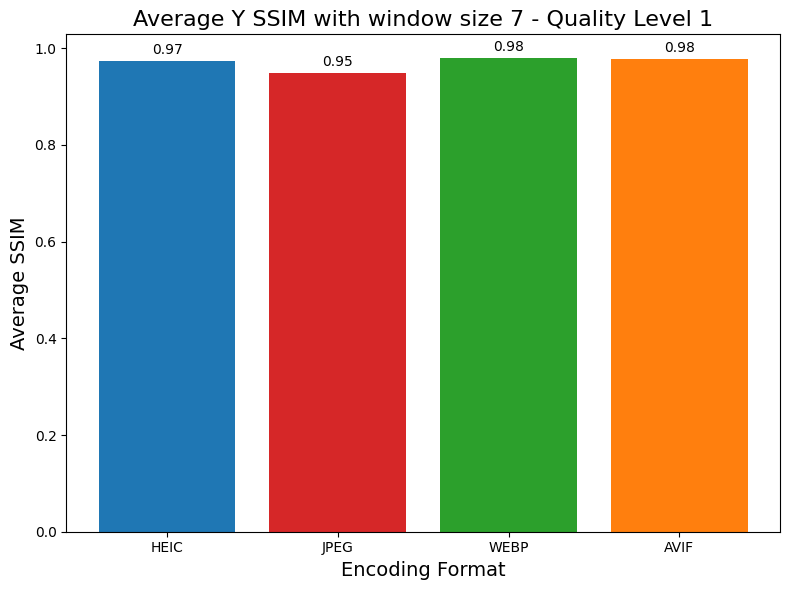

In [23]:
## Calculate average encoding time for each Format at each Quality Level
avg_ssim_df = df.groupby(['Quality_Level', 'Format'])['Y_SSIM_w7'].mean().reset_index()

# 4. Get the unique quality levels
quality_levels = sorted(df['Quality_Level'].unique())

# Define the order of formats to ensure consistency across charts
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 5. Create and save a separate plot for each quality level
for q_level in quality_levels:
    # Create a new independent figure for each quality level
    plt.figure(figsize=(8, 6))
    
    # Filter data for the current quality level
    subset = avg_ssim_df[avg_ssim_df['Quality_Level'] == q_level]
    
    # Extract times and colors in the specified order
    times = []
    colors = []
    labels = []
    
    for fmt in format_order:
        fmt_data = subset[subset['Format'] == fmt]
        if not fmt_data.empty:
            times.append(fmt_data['Y_SSIM_w7'].values[0])
            colors.append(color_map[fmt])
            labels.append(fmt)
            
    # Create the bar chart
    bars = plt.bar(labels, times, color=colors)
    
    # Formatting the plot
    plt.title(f'Average Y SSIM with window size 7 - Quality Level {q_level}', fontsize=16)
    plt.xlabel('Encoding Format', fontsize=14)
    plt.ylabel('Average SSIM', fontsize=14)
        
    # Add value labels on top of each bar for readability
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom')

    # Adjust layout to prevent clipping
    plt.tight_layout()
    
    # Save the individual figure
    plt.show()
    
    # Clear the current figure to start fresh for the next loop iteration
    plt.close()

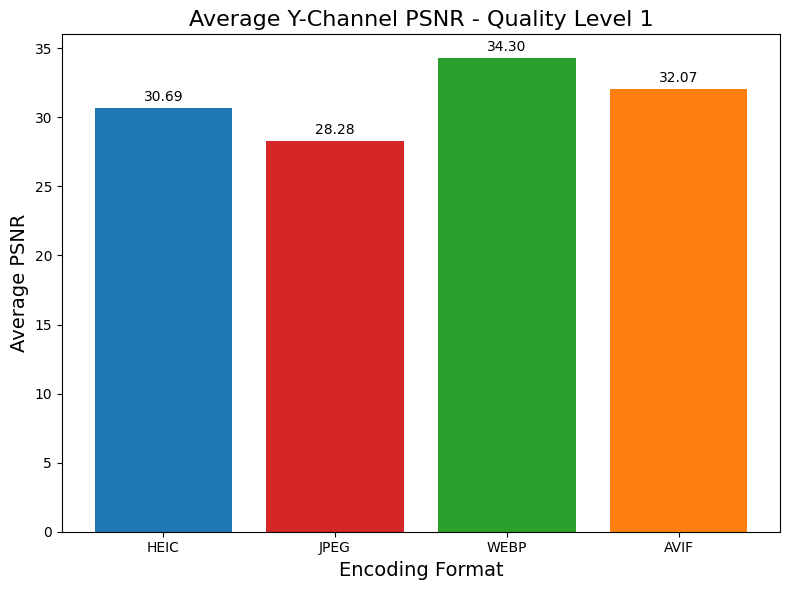

In [24]:
## Calculate average encoding time for each Format at each Quality Level
avg_psnr_df = df.groupby(['Quality_Level', 'Format'])['Y_PSNR'].mean().reset_index()

# 4. Get the unique quality levels
quality_levels = sorted(df['Quality_Level'].unique())

# Define the order of formats to ensure consistency across charts
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 5. Create and save a separate plot for each quality level
for q_level in quality_levels:
    # Create a new independent figure for each quality level
    plt.figure(figsize=(8, 6))
    
    # Filter data for the current quality level
    subset = avg_psnr_df[avg_psnr_df['Quality_Level'] == q_level]
    
    # Extract times and colors in the specified order
    times = []
    colors = []
    labels = []
    
    for fmt in format_order:
        fmt_data = subset[subset['Format'] == fmt]
        if not fmt_data.empty:
            times.append(fmt_data['Y_PSNR'].values[0])
            colors.append(color_map[fmt])
            labels.append(fmt)
            
    # Create the bar chart
    bars = plt.bar(labels, times, color=colors)
    
    # Formatting the plot
    plt.title(f'Average Y-Channel PSNR - Quality Level {q_level}', fontsize=16)
    plt.xlabel('Encoding Format', fontsize=14)
    plt.ylabel('Average PSNR', fontsize=14)
        
    # Add value labels on top of each bar for readability
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom')

    # Adjust layout to prevent clipping
    plt.tight_layout()
    
    # Save the individual figure
    plt.show()
    
    # Clear the current figure to start fresh for the next loop iteration
    plt.close()